In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re


In [3]:
# Load the JSONL file
file_path = '/home/nl97naca/results/attention-metric-mid-layers/vqa_stats.jsonl'
df = pd.read_json(file_path, lines=True)

In [ ]:
#df = df[df['is_correct'] == False]
#df = df[df['confusion_type'] == "FN"]
#df = df[df['relation_type'] == "perception"]
df

,image_id,query_prompt,response,label,relation_type,mllm_name,attention_metric_original,attention_metric_noised,is_correct,difference_pt
0,713858,What is the relation with bag and ground in th...,Bag is on ground.,bag is on ground.,perception,llava-v1.5-13b,60.857565,60.103918,True,-0.753647
1,2347642,What is the relation with stripes and kite in ...,Stripes are on the kite.,stripes are on kite.,perception,llava-v1.5-13b,93.870440,91.795311,True,-2.075129
2,2388748,What is the relation with man and stair railin...,man is riding skateboard down stair railing,man is on stair railing.,perception,llava-v1.5-13b,40.395310,20.265999,False,-20.129311
3,2320571,What is the relation with taxi and street in t...,Taxi is parked on the side of the street.,taxi is on street.,perception,llava-v1.5-13b,67.906160,47.804899,True,-20.101261
4,2334974,What is the relation with wing and statue in t...,Wing is above statue.,wing is on statue.,perception,llava-v1.5-13b,46.612962,31.638992,False,-14.973970
...,...,...,...,...,...,...,...,...,...,...
4865,2355963,What is the relation with people and luggage i...,people are loading luggage,people are loading luggage.,cognitive,llava-v1.5-13b,18.381056,13.225203,True,-5.155853
4866,2414832,What is the relation with people and trunk in ...,People are standing near the trunk.,people are loading trunk.,cognitive,llava-v1.5-13b,10.870124,8.963059,False,-1.907064
4867,2408015,What is the relation with vehicle and luggage ...,Vehicle is towing luggage.,vehicle is loading luggage.,cognitive,llava-v1.5-13b,45.398436,57.840231,False,12.441795
4868,2374233,What is the relation with subway train and pas...,Subway train is pulling into the station and p...,subway train is loading passengers.,cognitive,llava-v1.5-13b,18.087337,9.967055,False,-8.120282


Increase font size for SVG

In [10]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

# --- Global Configuration ---

# Assumption: Get the default title size from the original configuration
# This satisfies the "default" reference requirement.
default_title_raw = mpl.rcParamsDefault['axes.titlesize']
default_base_font = mpl.rcParamsDefault['font.size']

# Matplotlib font scale mapping for standard string labels
font_scale_map = {
    'xx-small': 0.579, 'x-small': 0.694, 'small': 0.833, 'medium': 1.0,
    'large': 1.2, 'x-large': 1.44, 'xx-large': 1.728,
}

# Resolve the numeric base size
if isinstance(default_title_raw, str):
    # Halt if the default label is not in our known mapping
    assert default_title_raw in font_scale_map, f"Unknown default font label: {default_title_raw}"
    base_title_size = default_base_font * font_scale_map[default_title_raw]
elif isinstance(default_title_raw, (int, float)):
    base_title_size = default_title_raw
else:
    raise TypeError(f"Unexpected type for axes.titlesize: {type(default_title_raw)}")

# Calculate the new fixed size: 1.5x the default title size
# target_size = 1.5 * base_title_size
new_fixed_size = 1.5 * base_title_size

# Apply changes globally
mpl.rcParams['axes.titlesize'] = new_fixed_size
mpl.rcParams['axes.labelsize'] = new_fixed_size

In [ ]:
#not idempotent:
df['attention_metric_noised'] *= 100
df['attention_metric_original'] *= 100

# Calculate difference in percentage points (%pt)
df['difference_pt'] = (df['attention_metric_noised'] - df['attention_metric_original'])

Text(0, 0.5, 'Question count')

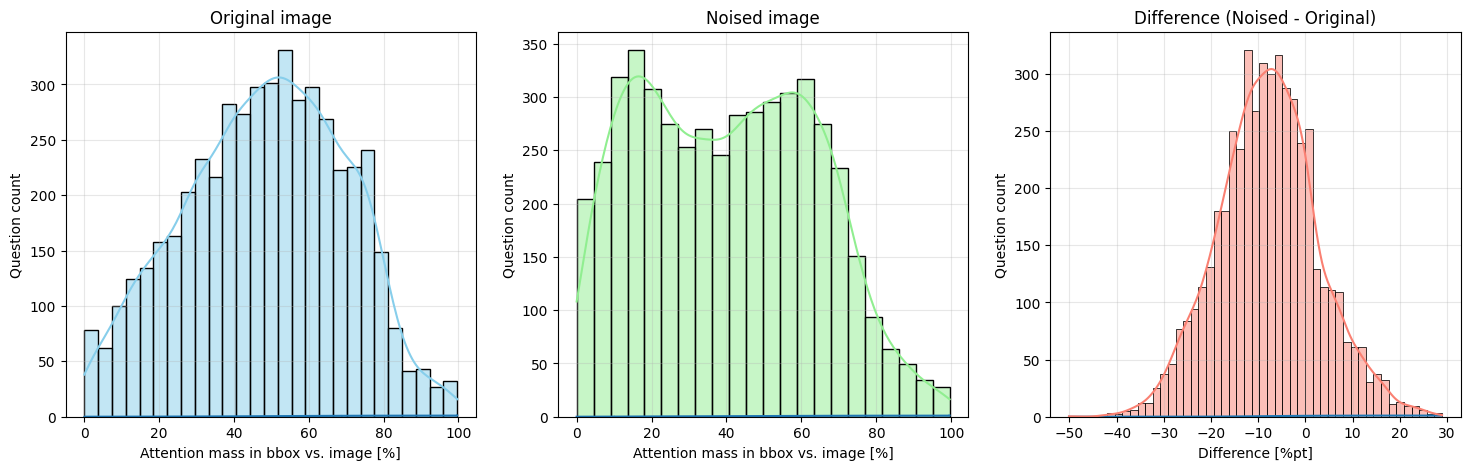

In [ ]:
# Function to plot ECDF
def plot_ecdf(data, ax, label, xlabel):
    x = np.sort(data)
    y = np.arange(1, len(x) + 1) / len(x)
    ax.step(x, y, where='post', label=label)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(r'$F_n(x)$')
    ax.grid(True, alpha=0.3)

# Generate plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

##ECDF
plot_ecdf(df['attention_metric_original'], axes[0], 'Original', 'Attention mass in bbox vs. image [%]')
axes[0].set_title('ECDF of Attention ratio on original image')

plot_ecdf(df['attention_metric_noised'], axes[1], 'Noised', 'Attention mass in bbox vs. image [%]')
axes[1].set_title('ECDF of Attention ratio on contrastive sample')

plot_ecdf(df['difference_pt'], axes[2], 'Difference', 'Difference [%pt]')
axes[2].set_title('ECDF of Difference (Noised - Original)')

##Histogram
# Plot 1: Original
sns.histplot(df['attention_metric_original'], ax=axes[0], kde=True, color='skyblue', edgecolor='black')
axes[0].set_title('Original image')
axes[0].set_xlabel('Attention mass in bbox vs. image [%]')
axes[0].set_ylabel('Question count')

# Plot 2: Noised
sns.histplot(df['attention_metric_noised'], ax=axes[1], kde=True, color='lightgreen', edgecolor='black')
axes[1].set_title('Noised image')
axes[1].set_xlabel('Attention mass in bbox vs. image [%]')
axes[1].set_ylabel('Question count')

# Plot 3: Difference
sns.histplot(df['difference_pt'], ax=axes[2], kde=True, color='salmon', edgecolor='black')
axes[2].set_title('Difference (Noised - Original)')
axes[2].set_xlabel('Difference [%pt]')
axes[2].set_ylabel('Question count')
#axes[2].axvline(0, color='red', linestyle='--', linewidth=1) # Reference line at 0

#plt.tight_layout()
#plt.show()
#plt.savefig('/home/nico/Desktop/attention-metric_yesno_llava-13b_layers-15-to-32_large-text.svg')